# AstraCell — The External-Plant Gate

**Does calibrated abstention survive a plant AstraCell did not write?**

Every version before this measured AstraCell against a battery *we* built. v0.1's mismatch was
four terms we chose, at sizes we set, so "the observer is simpler than the plant" was true by
construction. v0.3 is the first external-validity test: the data comes from a **PyBaMM** SPMe
single cell — electrolyte and particle diffusion a first-order ECM cannot express, a gap we did
not design. Same estimator, same gates; PyBaMM only supplies the voltage.

> ⚠️ **Still synthetic.** PyBaMM is a sophisticated *model*, not a measured cell. This tests
> external *model* mismatch, not physical truth. The four disclaimers are in
> [`docs/EXTERNAL_PLANT.md`](../docs/EXTERNAL_PLANT.md) §5. PyBaMM is an optional dependency
> (`pip install -e '.[pybamm]'`); the PyBaMM cells below skip cleanly without it, and the
> self-consistency control in §1 runs either way.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astracell.calibration import (
    NOMINAL_LEVELS,
    abstention_metrics,
    build_external_observer,
    coverage_curve,
    external_scenario,
    observer_voltage,
    prepare_external,
    pulse_profile,
    run_trials,
    two_sided_z,
)
from astracell.cell.ocv import NMC_LIKE, ocv_from_table
from astracell.plant import PYBAMM_AVAILABLE

plt.rcParams["figure.dpi"] = 110
SEED = 0
SOC0 = 0.9
N_TIME = 600
CAPACITY_AH = 5.0
CURRENT = pulse_profile(CAPACITY_AH, mean_c_rate=0.5, pulse_c_rate=1.0, n_time=N_TIME)

# PyBaMM-derived objects; populated in section 2 when the dependency is present.
observer = None
money_result = None

print("PyBaMM available:", PYBAMM_AVAILABLE)

PyBaMM available: True


---
## 1. A control that cannot be a harness bug

Before PyBaMM is involved, feed the *same* external-plant pipeline an **ECM-generated** trace.
There the model mismatch is exactly zero, so coverage must track nominal. If it does, any
collapse under PyBaMM later is the plant's mismatch and not a bug in the plumbing. This runs
with no PyBaMM — the observer here uses the built-in `NMC_LIKE` curve.

In [2]:
control_observer = build_external_observer(NMC_LIKE, CAPACITY_AH)
control_scn = external_scenario(name="control", observer=control_observer, current_a=CURRENT, soc0=SOC0)
control_prepared = prepare_external(control_scn, observer_voltage(control_scn))
control_result = run_trials(control_scn, 3000, seed=SEED, estimator="linear", prepared=control_prepared)

print(f"structural bias = {control_result.bias:+.4%}   (an ECM cannot mismatch itself)")
print(f"{'nominal':>10s} {'empirical coverage':>20s}")
for level, got in zip(NOMINAL_LEVELS, coverage_curve(control_result), strict=True):
    print(f"{level:10.0%} {got:20.1%}")
worst = max(abs(g - l) for g, l in zip(coverage_curve(control_result), NOMINAL_LEVELS, strict=True))
print(f"\nlargest deviation from nominal: {worst:.3f}  ->  the harness adds no bias of its own.")

structural bias = +0.0000%   (an ECM cannot mismatch itself)
   nominal   empirical coverage
       50%                50.1%
       80%                81.4%
       90%                90.6%
       95%                95.7%
       99%                98.8%

largest deviation from nominal: 0.014  ->  the harness adds no bias of its own.


---
## 2. The residual, and a phantom fault on a healthy cell

Now the real plant. The observer borrows PyBaMM's own pseudo-OCV (a slow C/20 discharge), so the
static voltage–SOC relationship is shared and the residual under load is purely the **dynamics**
the ECM omits. The cell is **healthy** — the true capacity deviation is zero — yet fitting the
ECM to PyBaMM's voltage manufactures a large, precise capacity fault out of the diffusion droop.

plant - observer residual: 20.65 mV RMS  (measurement noise is 1 mV)
true capacity deviation:      0.00%  (healthy cell)
estimated capacity deviation: -67.58% +/- 0.145% (1 sigma) -- 466 sigma from the truth


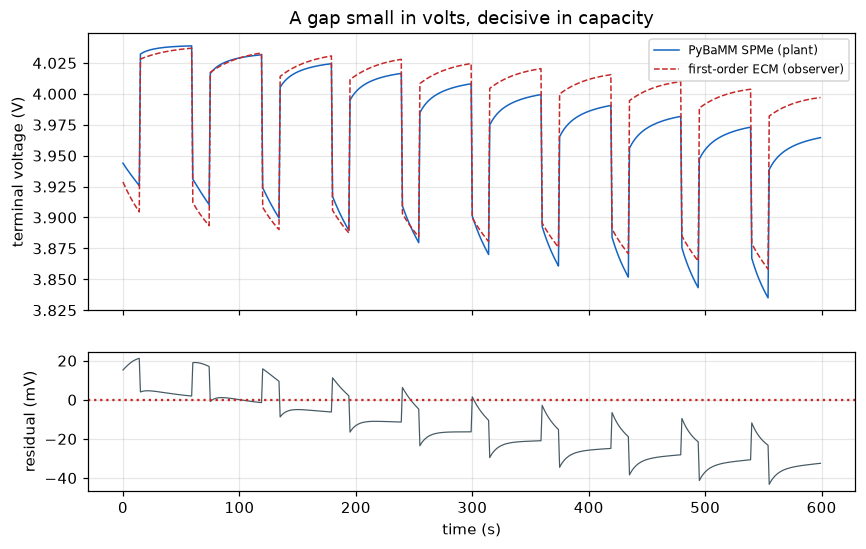

In [3]:
if PYBAMM_AVAILABLE:
    from astracell.plant import pybamm_pseudo_ocv, simulate_pybamm_cell

    soc, ocv = pybamm_pseudo_ocv(model="SPMe", n_points=200)
    curve = ocv_from_table(soc, ocv, name="pybamm_spme", chemistry="SPMe/Chen2020")
    observer = build_external_observer(curve, CAPACITY_AH)

    plant = simulate_pybamm_cell(CURRENT, 1.0, model="SPMe", soc0=SOC0)
    money_scn = external_scenario(name="pybamm", observer=observer, current_a=CURRENT, soc0=SOC0)
    obs_v = observer_voltage(money_scn)
    money_prepared = prepare_external(money_scn, plant.voltage_v)
    money_result = run_trials(money_scn, 500, seed=SEED, estimator="linear", prepared=money_prepared)

    residual_mv = 1e3 * (plant.voltage_v - obs_v)
    rms = float(np.sqrt(np.mean(residual_mv**2)))
    print(f"plant - observer residual: {rms:.2f} mV RMS  (measurement noise is 1 mV)")
    print(f"true capacity deviation:      0.00%  (healthy cell)")
    print(f"estimated capacity deviation: {money_result.delta_hat.mean():+.2%} "
          f"+/- {money_result.crlb_std:.3%} (1 sigma) -- "
          f"{abs(money_result.delta_hat.mean()) / money_result.crlb_std:.0f} sigma from the truth")

    t = np.arange(N_TIME)
    fig, (top, bottom) = plt.subplots(2, 1, figsize=(9, 5.4), sharex=True, height_ratios=[2, 1])
    top.plot(t, plant.voltage_v, color="#1565c0", lw=1.0, label="PyBaMM SPMe (plant)")
    top.plot(t, obs_v, color="#c62828", lw=1.0, ls="--", label="first-order ECM (observer)")
    top.set(ylabel="terminal voltage (V)", title="A gap small in volts, decisive in capacity")
    top.legend(fontsize=8); top.grid(alpha=0.3)
    bottom.plot(t, residual_mv, color="#455a64", lw=0.8); bottom.axhline(0, color="#c62828", ls=":")
    bottom.set(xlabel="time (s)", ylabel="residual (mV)"); bottom.grid(alpha=0.3)
    plt.show()
else:
    print("PyBaMM not installed -- skipping. Install with: pip install -e '.[pybamm]'")

---
## 3. Coverage before and after admitting the bias

The variance-only interval — pinned to ~0.15% around a centre 60-odd percent from zero — covers
the healthy truth essentially never. The control (ECM plant) sits on the diagonal, proving the
collapse is the plant. Widening the interval for the structural bias restores coverage above
80%, but only by becoming wide enough to be diagnostically useless.

 nominal   control (ECM)   PyBaMM var  PyBaMM bias-aware
     50%           50.1%         0.0%               0.0%
     80%           81.4%         0.0%             100.0%
     90%           90.6%         0.0%             100.0%
     95%           95.7%         0.0%             100.0%
     99%           98.8%         0.0%             100.0%


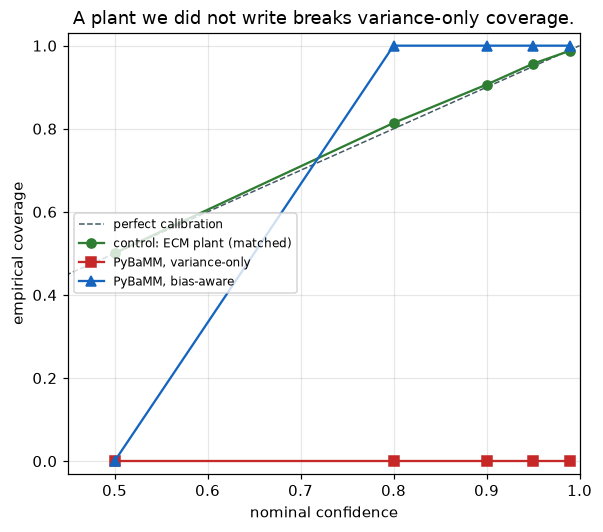

In [4]:
if PYBAMM_AVAILABLE and money_result is not None:
    cov_control = coverage_curve(control_result)
    cov_var = coverage_curve(money_result, bias_aware=False)
    cov_bias = coverage_curve(money_result, bias_aware=True)

    print(f"{'nominal':>8s} {'control (ECM)':>15s} {'PyBaMM var':>12s} {'PyBaMM bias-aware':>18s}")
    for lvl, cc, cv, cb in zip(NOMINAL_LEVELS, cov_control, cov_var, cov_bias, strict=True):
        print(f"{lvl:8.0%} {cc:15.1%} {cv:12.1%} {cb:18.1%}")

    fig, ax = plt.subplots(figsize=(6.0, 5.2))
    grid = np.array(NOMINAL_LEVELS)
    ax.plot([0, 1], [0, 1], ls="--", color="#455a64", lw=1.0, label="perfect calibration")
    ax.plot(grid, cov_control, "o-", color="#2e7d32", label="control: ECM plant (matched)")
    ax.plot(grid, cov_var, "s-", color="#c62828", label="PyBaMM, variance-only")
    ax.plot(grid, cov_bias, "^-", color="#1565c0", label="PyBaMM, bias-aware")
    ax.set(xlabel="nominal confidence", ylabel="empirical coverage", xlim=(0.45, 1.0),
           ylim=(-0.03, 1.03), title="A plant we did not write breaks variance-only coverage.")
    ax.legend(fontsize=8, loc="center left"); ax.grid(alpha=0.3)
    plt.show()
else:
    print("PyBaMM not installed -- skipping the coverage comparison.")

---
## 4. Harmful overclaim across excitation, with and without the gate

Without the gate the observer diagnoses the phantom fault in **every trial at every C-rate**. The
bias gate — reading its own fit residual to estimate its bias — refuses instead, driving harmful
overclaim to zero. Note the phantom fault's *size* swings with C-rate and even flips sign: its
instability is the proof that it is model mismatch, not a real capacity loss. What is robust is
the overclaim and the refusal.

 mean C  phantom fault    sigma   no gate   gated


   0.2C       +113.9%   0.675%      1.00    0.00


   0.3C        -19.5%   0.344%      1.00    0.00


   0.5C        -67.6%   0.145%      1.00    0.00


   0.8C        -59.2%   0.083%      1.00    0.00


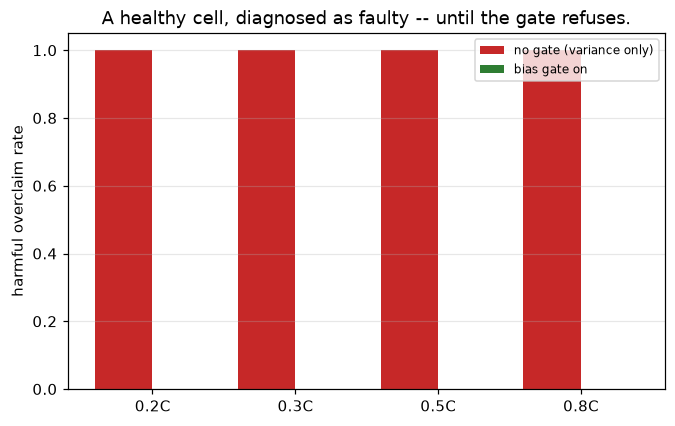

In [5]:
if PYBAMM_AVAILABLE:
    from astracell.plant import simulate_pybamm_cell

    c_rates = (0.2, 0.3, 0.5, 0.8)
    gated_rates, ungated_rates = [], []
    print(f"{'mean C':>7s} {'phantom fault':>14s} {'sigma':>8s} {'no gate':>9s} {'gated':>7s}")
    for mean_c in c_rates:
        cur = pulse_profile(CAPACITY_AH, mean_c_rate=mean_c, pulse_c_rate=1.0, n_time=N_TIME)
        pl = simulate_pybamm_cell(cur, 1.0, model="SPMe", soc0=SOC0)
        g_scn = external_scenario(name="g", observer=observer, current_a=cur, soc0=SOC0)
        g_prep = prepare_external(g_scn, pl.voltage_v)
        u_scn = external_scenario(name="u", observer=observer, current_a=cur, soc0=SOC0,
                                  use_bias_gate=False)
        u_prep = prepare_external(u_scn, pl.voltage_v)
        g = abstention_metrics(run_trials(g_scn, 300, seed=SEED, prepared=g_prep))
        u = abstention_metrics(run_trials(u_scn, 300, seed=SEED, prepared=u_prep))
        gated_rates.append(g.harmful_overclaim_rate)
        ungated_rates.append(u.harmful_overclaim_rate)
        print(f"{mean_c:6.1f}C {g_prep.target_bias:+13.1%} {g_prep.target_sigma:8.3%} "
              f"{u.harmful_overclaim_rate:9.2f} {g.harmful_overclaim_rate:7.2f}")

    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    x = np.arange(len(c_rates))
    ax.bar(x - 0.2, ungated_rates, 0.4, color="#c62828", label="no gate (variance only)")
    ax.bar(x + 0.2, gated_rates, 0.4, color="#2e7d32", label="bias gate on")
    ax.set(xticks=x, xticklabels=[f"{c:.1f}C" for c in c_rates], ylabel="harmful overclaim rate",
           ylim=(0, 1.05), title="A healthy cell, diagnosed as faulty -- until the gate refuses.")
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
    plt.show()
else:
    print("PyBaMM not installed -- skipping the excitation sweep.")

---
## What this notebook validated, and what it did not

**Validated (synthetically, against a plant we did not design):**

- The external-plant harness is unbiased: fed an ECM trace, it covers at nominal (§1).
- Fed a **PyBaMM** cell, the same first-order ECM reports a large, precise capacity fault on a
  *healthy* cell, and the variance-only interval covers the truth essentially never (§2–3).
- The bias gate converts those overclaims into refusals at every excitation — harmful overclaim
  100% → 0% (§4). Under an honest plant, AstraCell diagnoses *less*.

**Not validated, and not claimable:**

- Anything about a **real battery**. PyBaMM is a model; this is external *model* mismatch, not
  physical truth.
- The *magnitude* of the phantom fault. It swings with C-rate and with the observer's RC tuning
  ([`docs/EXTERNAL_PLANT.md`](../docs/EXTERNAL_PLANT.md) §3d); only the direction — precise, biased,
  therefore refused — is robust. An earlier draft calling it "robust to R1/C1" was wrong and was
  retracted.
- A recovered *injected* fault. The mismatch here is the model-order gap on a sound cell; PyBaMM-side
  degradation (and the DFN) is deferred.

Full accounting: [`docs/EXTERNAL_PLANT.md`](../docs/EXTERNAL_PLANT.md) and
[`LIMITATIONS.md`](../LIMITATIONS.md) §14.